# Seminar 2.  Sequential Bayesian Learning

In [1]:
import numpy as np
from scipy.stats import multivariate_normal as mvn
from numpy.polynomial.polynomial import polyval
import matplotlib.pyplot as plt

%matplotlib inline

We consider the following model:

- Likelihood model for one item from data : $p(y_n|x_n, w;\beta) = \mathcal{N}(y_n| \textbf{w}^Tx_n, \beta^{-1})$
- Likelihood model for whole data: $p(\textbf{y}|X,\textbf{w};\beta) = \prod\limits_{n=1}^{N}p(y_n|x_n,\textbf{w};\beta) = \mathcal{N}(\textbf{y}|X\textbf{w}, \beta^{-1})$
- Prior: $p(\textbf{w};\alpha) = \prod\limits_{d=1}^{D}\mathcal{N}(w_d|0, \alpha_d^{-1})=\mathcal{N}(\textbf{w}|0,A^{-1})$
    

And for sequential updates we come up with the following equations:


- Observe $(X,\textbf{t})^{1}$ and obtain:

    $$\Sigma_{w}^{-1} = [\beta X_{(1)}^TX_{(1)} + A]$$
    $$\mu_{w} = \Sigma_{w}\beta X^T_{(1)}\textbf{t}_{(1)}$$
    
    
- Observe $(X,\textbf{t})^{2}$ and then for joint data:

    $$\Sigma_{w,(1,2)}^{-1} = [\beta X_{(2)}^T X_{(2)} + \Sigma_{w}^{-1}]$$
    
    $$\mu_{w,(1,2)} = \Sigma_{w,(1,2)}(\beta X_{(2)}^T\textbf{t}_{(2)}+\Sigma^{-1}_w\mu_w)$$

- $\dots$

### Task 1

Here, we define our model:

- $\textit{init}$ takes $\beta$ for likelihood model and W_pr constitutes parameters of current prior
- $\textit{update_w}$ is calculation of parameters of current posterior(future prior)
- $\textit{plot_w_space}$ makes plotting of current posterior distribution

In [2]:
class BLR:
    def __init__(self, A, beta, x_dim=2):
        self.w_Pr = {"mu": np.zeros(x_dim), "cov": np.linalg.inv(A), "inv_cov": A}
        self.beta = beta

    def update_w(self, X, y, verbose=False):
        inv_cov = self.beta * X.T @ X + self.w_Pr["inv_cov"]
        cov = np.linalg.inv(inv_cov)
        mu = cov @ (
            self.beta * X.T @ y[:, None]
            + self.w_Pr["inv_cov"] @ self.w_Pr["mu"][:, None]
        )

        self.w_Pr = {"mu": mu.flatten(), "cov": cov, "inv_cov": inv_cov}
        return {"mu": mu.flatten(), "cov": cov, "inv_cov": inv_cov} if verbose else 0.0

    def plot_w_space(self, ax, b=15.0):
        xx, yy = np.mgrid[-b:b:0.01, -b:b:0.01]
        grid = np.c_[xx.ravel(), yy.ravel()]
        probs = mvn.logpdf(grid, mean=self.w_Pr["mu"], cov=self.w_Pr["cov"])
        contour = ax.contourf(xx, yy, probs.reshape(xx.shape))

    def plot_data_space(self, x, y, ax):
        a, b = (-1.1, 1.1)
        for i in range(50):
            w = np.random.multivariate_normal(self.w_Pr["mu"], self.w_Pr["cov"])
            ax.plot(
                np.array([a, b]),
                np.array([w[0] + w[1] * a, w[0] + w[1] * b]),
                "r-",
                alpha=0.15,
            )

        ax.scatter(
            x[:, :, 1].flatten(),
            y.flatten(),
            edgecolor="white",
            alpha=0.75,
            color="blue",
        )
        ax.scatter(
            x[-1, :, 1].flatten(),
            y[-1].flatten(),
            edgecolor="white",
            alpha=1.0,
            color="green",
        )

    def plot_poly_data_space(self, x, y, ax, k=2):
        k_points = np.linspace(-1.1, 1.1, num=k + 1)
        for i in range(50):
            w = np.random.multivariate_normal(self.w_Pr["mu"], self.w_Pr["cov"])
            poly_values = np.zeros_like(k_points)
            poly_values = polyval(k_points, w)
            ax.plot(k_points, poly_values, "r-", alpha=0.15)

        ax.scatter(
            x[:, :, 1].flatten(),
            y.flatten(),
            edgecolor="white",
            alpha=0.75,
            color="blue",
        )
        ax.scatter(
            x[-1, :, 1].flatten(),
            y[-1].flatten(),
            edgecolor="white",
            alpha=1.0,
            color="green",
        )

In [3]:
reg = BLR(np.diag([0.1, 0.1]), 1.0)

In [4]:
# make matrice X
x1 = np.linspace(-1, 1, 10)
np.random.shuffle(x1)
x1 = x1.reshape(5, 2)
x0 = np.ones_like(x1)
X = np.stack([x0, x1], axis=-1)

# make targets y
y = 1.5 + 12.0 * x1
y += np.random.randn(*y.shape) * 3.5

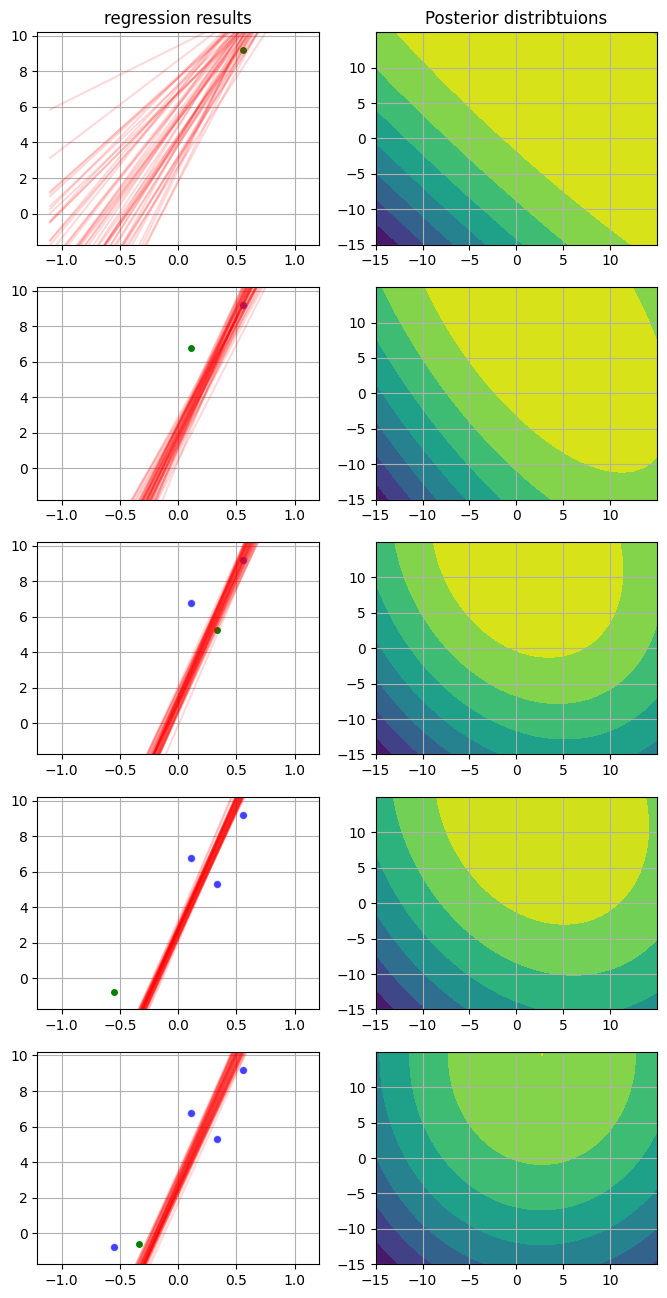

In [5]:
chunks = 5  # divide dataset to 5 parts (M=5)

# plotting utils
fig, ax = plt.subplots(chunks, 2, figsize=(8, 16))
ymin, ymax = y[:, 1].min(), y[:, 1].max()
yrange = ymax - ymin
ymin, ymax = ymin - 0.1 * yrange, ymax + 0.1 * yrange

for i in range(chunks):
    reg.update_w(X[i], y[i])
    reg.plot_data_space(X[: i + 1], y[: i + 1], ax[i, 0])
    ax[i, 0].set_ylim(ymin, ymax)
    reg.plot_w_space(ax[i, 1])
    ax[i, 0].grid(), ax[i, 1].grid()
    ax[0, 0].set_title("regression results")
    ax[0, 1].set_title("Posterior distribtuions")